In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

# List the contents of the root directory of your Google Drive
print(os.listdir('/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/data_train/data_final_train_v1/'))

['generate_training_triplet_4347.py', 'data_train_singlequery.pkl', 'splits', 'cosine_results_v1_model_bkai.csv', 'bge_rerank_scored.csv', 'cosine_results_v1.csv', 'cosine_results_v1_model_e5.csv', 'data_filtered_v1.pkl', 'data_train_v1.pkl']


In [4]:
import pickle
# LOAD PKL DATA
data_test = '/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/data_train/data_final_train_v1/data_train_v1.pkl'
with open(data_test, "rb") as f:
     data = pickle.load(f)
print(f"Loaded {len(data)} QA pairs.\n")

Loaded 25153 QA pairs.



In [5]:
from sentence_transformers import CrossEncoder
import pandas as pd
import torch

# 1. LOAD MODEL (Dùng class CrossEncoder)
# ===============================
model_id = 'BAAI/bge-reranker-v2-m3'
# Load model vào GPU nếu có
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = CrossEncoder(model_id, device=device)

# 2. TÍNH SCORE (Dùng hàm predict)
# ===============================
results_v2 = []

for idx, item in enumerate(data):      # data: list[InputExample]
    query, positive = item.texts

    # --- SỬA ĐỔI QUAN TRỌNG ---
    # Thay vì encode riêng lẻ, ta đưa cả cặp vào hàm predict
    # Hàm predict nhận list các cặp: [[query, passage]]
    score = model.predict([(query, positive)])[0]

    # Chuyển về float python (score có thể là numpy float)
    score = float(score)

    # Lưu kết quả
    results_v2.append({
        "index": idx,
        "query": query,
        "positive": positive,
        "score": score, # Đổi tên 'cosine' thành 'score' cho đúng bản chất
    })

    # === IN RA TỪNG MẪU ===
    print(f"--- Sample {idx+1}/{len(data)} | Score: {score:.4f} ---")

# ===============================
df = pd.DataFrame(results_v2)

# Xem thống kê điểm số để chọn ngưỡng lọc (threshold)
print("\nThống kê điểm số:")
print(df['score'].describe())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
--- Sample 20165/25153 | Score: 0.9848 ---
--- Sample 20166/25153 | Score: 0.9877 ---
--- Sample 20167/25153 | Score: 0.9984 ---
--- Sample 20168/25153 | Score: 0.9972 ---
--- Sample 20169/25153 | Score: 0.9994 ---
--- Sample 20170/25153 | Score: 0.9753 ---
--- Sample 20171/25153 | Score: 0.9997 ---
--- Sample 20172/25153 | Score: 0.9968 ---
--- Sample 20173/25153 | Score: 0.9936 ---
--- Sample 20174/25153 | Score: 0.9885 ---
--- Sample 20175/25153 | Score: 0.9985 ---
--- Sample 20176/25153 | Score: 0.9975 ---
--- Sample 20177/25153 | Score: 0.9984 ---
--- Sample 20178/25153 | Score: 0.9972 ---
--- Sample 20179/25153 | Score: 0.9914 ---
--- Sample 20180/25153 | Score: 0.9907 ---
--- Sample 20181/25153 | Score: 0.9911 ---
--- Sample 20182/25153 | Score: 0.9984 ---
--- Sample 20183/25153 | Score: 0.9942 ---
--- Sample 20184/25153 | Score: 0.9926 ---
--- Sample 20185/25153 | Score: 0.9007 ---
--- Sample 20186/25153 | Score: 0.7601 -

In [6]:
# 3. LƯU KẾT QUẢ (PHẦN BẠN CẦN)
# ===============================
# Định nghĩa đường dẫn file (Dùng đúng thư mục Google Drive của bạn)
folder_path = '/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/data_train/data_final_train_v1/'
file_name = 'bge_rerank_scored_v1.csv'
output_path = os.path.join(folder_path, file_name)
# Lưu file
# encoding='utf-8-sig': Quan trọng để mở Excel không lỗi font tiếng Việt
# index=False: Không lưu cột số thứ tự thừa
df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"✅ Đã lưu thành công file tại: {output_path}")

✅ Đã lưu thành công file tại: /content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/data_train/data_final_train_v1/bge_rerank_scored_v1.csv


In [29]:
import pandas as pd

# ===============================
# 0. LOAD
# ===============================
df_cross = pd.read_csv(
    '/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/data_train/data_final_train_v1/bge_rerank_scored_v1.csv',
    encoding="utf-8"
)
total = len(df_cross)
# df_cross = df_cross[:24606]

# ===============================
# 0.5 LOẠI BỎ CẶP TRÙNG (NEW!)
# ===============================
before = len(df_cross)

df_cross["pair_key"] = df_cross["query"].astype(str).str.strip() + " ||| " + df_cross["positive"].astype(str).str.strip()
df_cross = df_cross.drop_duplicates(subset=["pair_key"]).drop(columns=["pair_key"])

after = len(df_cross)

print("===== LOẠI TRÙNG TRƯỚC KHI TÍNH SCORE =====")
print(f"Số mẫu trước khi lọc trùng:  {before}")
print(f"Số mẫu sau khi lọc trùng:    {after}")
print(f"Đã xóa trùng:               {before - after}")
print("============================================\n")

# ===============================
# 1. THRESHOLD + đánh dấu pass/fail
# ===============================
threshold = 0.8
df_cross["pass"] = df_cross["score"] >= threshold

# ===============================
# 2. THỐNG KÊ
# ===============================
# total = len(df_cross)
passed = int(df_cross["pass"].sum())
failed = total - passed

mean_score = float(df_cross["score"].mean())
min_score  = float(df_cross["score"].min())
max_score  = float(df_cross["score"].max())

print("========== THỐNG KÊ ==========")
print(f"Tổng số mẫu:         {total}")
print(f"Số mẫu PASS:         {passed}")
print(f"Số mẫu FAIL:         {failed}")
print(f"TỶ LỆ PASS:          {passed/total*100:.2f}%")
print("--------------------------------")
print(f"score TB:            {mean_score:.4f}")
print(f"score thấp nhất:     {min_score:.4f}")
print(f"score cao nhất:      {max_score:.10f}")
print("================================\n")

# ===============================
# 3. TOP FAIL
# ===============================
df_cross_fail = df_cross[~df_cross["pass"]].sort_values("score", ascending=True)

print(f"Số cặp FAIL (score < {threshold}): {len(df_cross_fail)}\n")

# ===============================
# 4. In score = 1.0
# ===============================
print("\n===== CÁC CẶP CÓ SCORE = 1.0 =====")
df_score_1 = df_cross[df_cross["score"] == 1.0]

if not df_score_1.empty:
    print(f"Tìm thấy {len(df_score_1)} cặp score = 1.0")
    for idx, r in df_score_1.iterrows():
        print("="*80)
        print(f"Index   : {idx}")
        print(f"Score   : {float(r['score']):.4f}")
        print(f"Query   : {str(r.get('query', ''))[:200]}")
        print(f"Positive: {str(r.get('positive', ''))[:300]}")
else:
    print("Không tìm thấy cặp score = 1.0")
# ===============================
# 5. CHUYỂN NGƯỢC VỀ LIST InputExample (E5 style)
# ===============================
# ... (Các phần từ 0 đến 4 giữ nguyên) ...

# ===============================
# 5. CHUYỂN NGƯỢC VỀ LIST InputExample (CÓ LỌC ĐIỂM)
# ===============================
import pickle
from sentence_transformers import InputExample

filtered_data = []

# LẤY RA DATA ĐẠT CHUẨN (PASS)
df_final_save = df_cross[df_cross["pass"] == True]

print(f"\n🚀 Đang tạo InputExample từ {len(df_final_save)} mẫu đạt chuẩn (Score >= {threshold})...")

for _, row in df_final_save.iterrows():
    # Lưu ý: Nếu bạn muốn chuẩn E5 (có prefix "query: ", "passage: ")
    # thì hãy thêm vào đây. Nếu model BKAI không cần prefix thì để nguyên.
    query_text = str(row["query"])
    pos_text   = str(row["positive"])

    # Ví dụ nếu muốn thêm prefix E5 (Bỏ comment dòng dưới nếu cần):
    # query_text = f"query: {query_text}"
    # pos_text   = f"passage: {pos_text}"

    filtered_data.append(InputExample(texts=[query_text, pos_text]))

# ===============================
# 6. LƯU FILE PKL
# ===============================
output_pkl = "/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/data_train/data_final_train_v1/data_filtered_v1_25153.pkl"

print(f"💾 Đang lưu {len(filtered_data)} mẫu vào file PKL...")
with open(output_pkl, "wb") as f:
    pickle.dump(filtered_data, f)

print("🎉 DONE! Đã lưu file thành công.")
print("📄 File output:", output_pkl)

===== LOẠI TRÙNG TRƯỚC KHI TÍNH SCORE =====
Số mẫu trước khi lọc trùng:  25153
Số mẫu sau khi lọc trùng:    24606
Đã xóa trùng:               547

========== THỐNG KÊ ==========
Tổng số mẫu:         25153
Số mẫu PASS:         23628
Số mẫu FAIL:         1525
TỶ LỆ PASS:          93.94%
--------------------------------
score TB:            0.9640
score thấp nhất:     0.0041
score cao nhất:      0.9999682903

Số cặp FAIL (score < 0.8): 978


===== CÁC CẶP CÓ SCORE = 1.0 =====
Không tìm thấy cặp score = 1.0

🚀 Đang tạo InputExample từ 23628 mẫu đạt chuẩn (Score >= 0.8)...
💾 Đang lưu 23628 mẫu vào file PKL...
🎉 DONE! Đã lưu file thành công.
📄 File output: /content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/data_train/data_final_train_v1/data_filtered_v1_25153.pkl


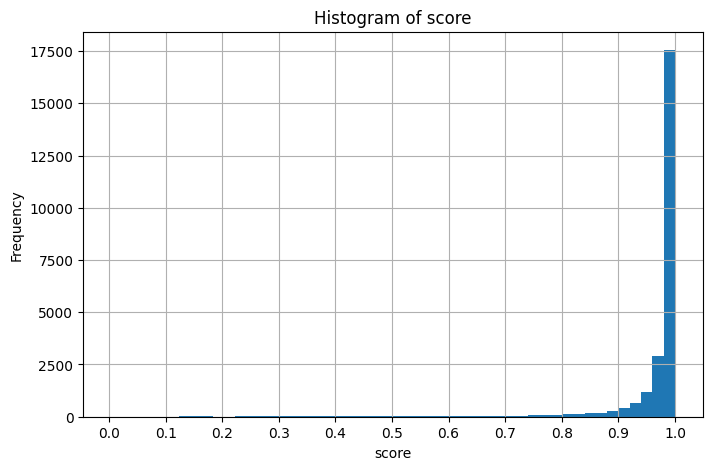

In [18]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

plt.figure(figsize=(8,5))
plt.hist(df_cross["score"], bins=50)
plt.title("Histogram of score")
plt.xlabel("score")
plt.ylabel("Frequency")
plt.grid(True)

# Chia nhãn trục x mỗi 0.1 (hoặc tùy ý)
plt.gca().xaxis.set_major_locator(MultipleLocator(0.1))

plt.show()


**Cosine similary**

In [21]:
from sentence_transformers import util
import pickle
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer, util
import matplotlib.pyplot as plt

# ===============================
# 1. LOAD MODEL + LOAD PKL DATA
# ===============================
#  LOAD MODEL
model = SentenceTransformer("intfloat/multilingual-e5-base")
# BAAI/bge-reranker-v2-m3
# 2. TÍNH COSINE
# ===============================
results = []
for idx, item in enumerate(data):      # data: list[InputExample] (texts=[query, positive])
    query, positive = item.texts

    # Encode
    query_emb = model.encode(query)
    pos_emb   = model.encode(positive)

    # Score
    score = float(util.cos_sim(query_emb, pos_emb))

    # Lưu kết quả
    results.append({
        "index": idx,
        "query": query,
        "positive": positive,
        "cosine": score,
    })
    # === IN RA TỪNG MẪU ===
    print(f"--- Sample {idx+1}/{len(data)} cosine: {score} ---")

# ===============================
df = pd.DataFrame(results)
# LƯU RA FILE CSV
output_path = '/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/data_train/data_final_train_v1/cosine_results_v1_model_e5_25153.csv'  # đổi tên / đường dẫn nếu muốn
df.to_csv(output_path, index=False, encoding="utf-8-sig")

print(f"✅ Đã lưu {len(df)} dòng vào file: {output_path}")

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
--- Sample 20155/25153 cosine: 0.8944331407546997 ---
--- Sample 20156/25153 cosine: 0.8835063576698303 ---
--- Sample 20157/25153 cosine: 0.8855257034301758 ---
--- Sample 20158/25153 cosine: 0.8853558301925659 ---
--- Sample 20159/25153 cosine: 0.8975695371627808 ---
--- Sample 20160/25153 cosine: 0.893558144569397 ---
--- Sample 20161/25153 cosine: 0.897457480430603 ---
--- Sample 20162/25153 cosine: 0.8572605848312378 ---
--- Sample 20163/25153 cosine: 0.9144731760025024 ---
--- Sample 20164/25153 cosine: 0.9063928723335266 ---
--- Sample 20165/25153 cosine: 0.894005298614502 ---
--- Sample 20166/25153 cosine: 0.9046956896781921 ---
--- Sample 20167/25153 cosine: 0.874966025352478 ---
--- Sample 20168/25153 cosine: 0.9157835245132446 ---
--- Sample 20169/25153 cosine: 0.935434103012085 ---
--- Sample 20170/25153 cosine: 0.8814724683761597 ---
--- Sample 20171/25153 cosine: 0.9287495613098145 ---
--- Sample 20172/25153 cosine:

In [23]:
import pandas as pd
import numpy as np

# ========= LOAD =========
df_cosine = pd.read_csv(
    "/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/data_train/data_final_train_v1/cosine_results_v1_model_e5_25153.csv",
    encoding="utf-8"
)

df_cross = pd.read_csv(
    "/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/data_train/data_final_train_v1/bge_rerank_scored_v1.csv",
    encoding="utf-8"
)

# ====== MERGE ======
df = df_cosine.merge(df_cross[["index", "score"]], on="index", how="left")

# ép kiểu
df["cosine"] = pd.to_numeric(df["cosine"], errors="coerce")
df["score"]  = pd.to_numeric(df["score"], errors="coerce")

# ===============================
# 1. THRESHOLD + ĐÁNH DẤU PASS
# ===============================
threshold = 0.8

df["pass_cosine"] = df["cosine"] >= threshold
df["pass_rerank"] = df["score"]  >= threshold

# Require BOTH cosine & rerank đạt threshold
df["pass_both"] = df["pass_cosine"] & df["pass_rerank"]

# ===============================
# 2. THỐNG KÊ
# ===============================
total = len(df)
passed = int(df["pass_both"].sum())
failed = total - passed

mean_score = float(df["cosine"].mean())
min_score  = float(df["cosine"].min())
max_score  = float(df["cosine"].max())

print("========== THỐNG KÊ ==========")
print(f"Tổng số mẫu:         {total}")
print(f"Số mẫu PASS:         {passed}")
print(f"Số mẫu FAIL:         {failed}")
print(f"TỶ LỆ PASS:          {passed/total*100:.2f}%")
print("--------------------------------")
print(f"Cosine TB:           {mean_score:.4f}")
print(f"Cosine thấp nhất:    {min_score:.4f}")
print(f"Cosine cao nhất:     {max_score:.4f}")
print("================================\n")

# ===============================
# 3. Soi các cặp FAIL
# ===============================
df_fail = df[~df["pass_both"]].sort_values("cosine", ascending=True)

print(f"Số cặp bị đánh dấu FAIL (cosine < {threshold} hoặc rerank < {threshold}): {len(df_fail)}\n")

print("===== TOP 10 FAIL THẤP NHẤT =====")
for _, r in df_fail.head(10).iterrows():
    print("="*80)
    print(f"Index   : {r['index']}")
    print(f"Cosine  : {r['cosine']:.4f}")
    print(f"Rerank  : {r['score']:.4f}")
    print(f"Query   : {r['query'][:200]}")
    print(f"Positive: {r['positive'][:200]}")


# ===============================
# 4. LỌC CẶP PASS
# ===============================
df_pass = df[df["pass_both"] == True].copy()

print(f"\nSố lượng cặp PASS_BOTH sẽ được lưu: {len(df_pass)}")


# ===============================
# 5. CHUYỂN NGƯỢC VỀ LIST InputExample (E5 style)
# ===============================
import pickle
from sentence_transformers import InputExample

filtered_data = []

for _, row in df_pass.iterrows():
    query_text = str(row["query"])
    pos_text   = str(row["positive"])
    filtered_data.append(InputExample(texts=[query_text, pos_text]))


# ===============================
# 6. LƯU FILE PKL
# ===============================
output_pkl = "/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/data_train/data_final_train_v1/data_filtered_v1.pkl"

with open(output_pkl, "wb") as f:
    pickle.dump(filtered_data, f)

print("🎉 DONE! Đã lưu file PKL dạng E5 prefix.")
print("📄 File output:", output_pkl)

========== THỐNG KÊ ==========
Tổng số mẫu:         25153
Số mẫu PASS:         24151
Số mẫu FAIL:         1002
TỶ LỆ PASS:          96.02%
--------------------------------
Cosine TB:           0.8873
Cosine thấp nhất:    0.7801
Cosine cao nhất:     0.9574

Số cặp bị đánh dấu FAIL (cosine < 0.8 hoặc rerank < 0.8): 1002

===== TOP 10 FAIL THẤP NHẤT =====
Index   : 23185
Cosine  : 0.7801
Rerank  : 0.7717
Query   : query: Nơi đây ngày xưa nổi tiếng với nghề gì?
Positive: passage: Ngày xưa, nơi đây còn là vựa gạo rất lớn của Sài Gòn – Chợ Lớn. Bên cạnh gia đình anh Văn còn nhiều hàng xóm láng giềng khác cùng nương tựa lẫn nhau. Anh mua gạo ủng hộ về làm hủ tiếu, ngược 
Index   : 18771
Cosine  : 0.7819
Rerank  : 0.0054
Query   : query: Những trò chơi nào có tại công viên giải trí này?
Positive: passage: + Chiếc Ô Kỳ Diệu: Xoay tròn dưới mái vòm của chiếc ô khổng lồ đầy màu sắc. Mang đến cảm giác phiêu bồng, nhẹ nhàng giữa không trung. Chiếc Ô Kỳ Diệu + Vũ Điệu Cốc Xoay: Lấy cảm hứng từ những